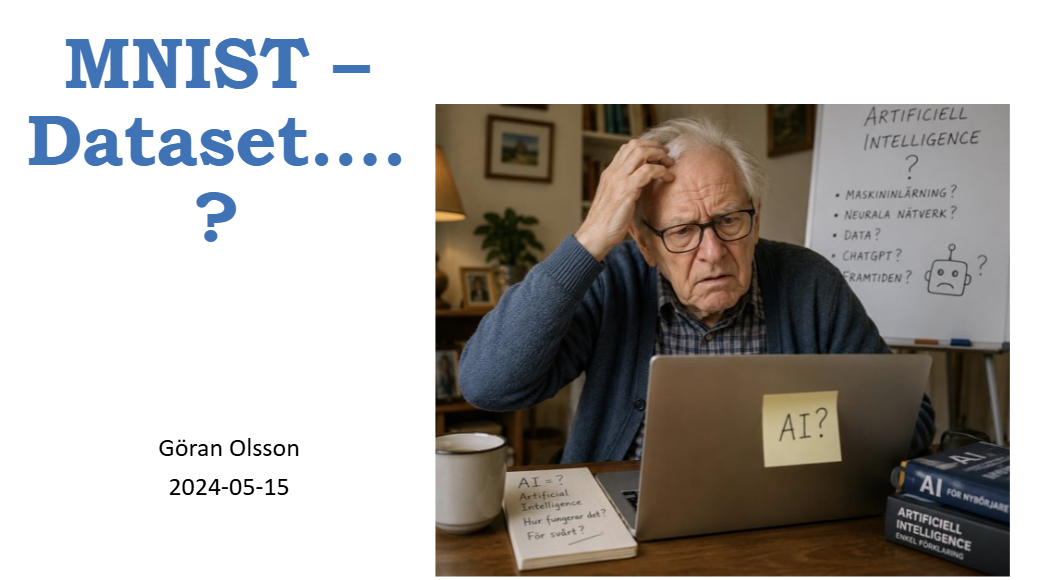

## Dokumenten

https://gosolna-commits.github.io/yh-kunskapskontroll-ai-index/

https://github.com/gosolna-commits/YH-Kunskapskontroll-AI
Göran_kunskapskontroll_AI.ipynb
Göran_kunskapskontroll_AI_frågorna.ipynb

https://github.com/gosolna-commits/mnist-pics
mnist-pics.py

https://github.com/gosolna-commits/mnist-mlp-cnn
app.py
mlp_model.pkl
cnn_model.keras

https://github.com/gosolna-commits/mnist-cnn
Göran_ML_CNN_sparad.py

https://github.com/gosolna-commits/mnist-LogReg
Göran_ML_LogReg.py


## Funderingar

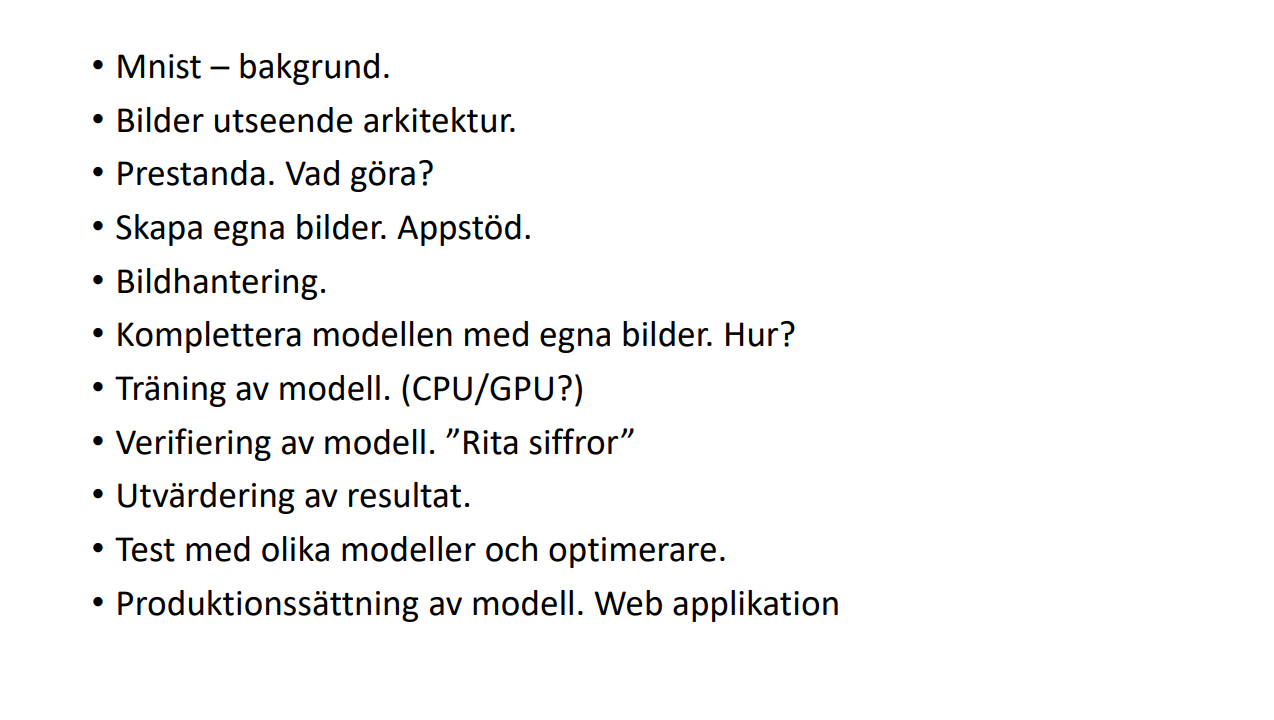

# ML - projekt

## - 1.  Datainsamling
## - 2.  Data förberedelse
## - 3.  Dela upp data
## - 4.  Feature engineering   
## - 5.  Välj modell
## - 6.  Träna modell
## - 7.  Utvärdera modell
## - 8.  Tuning och förbättring     
## - 9.  Deployment
## - 10. Övervakning

# Inledning

MNIST är ett dataset med 70.000 biler på siffror 0-9.
Datasetet är uppdelat i träning och test biler, 60.000 resp. 10.000.
Varje bild är märkt med siffra som stämmer överens med bilden.
Det är enkelt och välstrukturerat och bra för träning och undervisning.
Användningsområde.
- Träning och test av klassificeringsmodeller.
- Introduktion till neurala nätverk
- Optimering och utvärdering av prestationsförmåga.

# 1. Datainsamling

### Förklaring av datainsamling
Denna kod laddar in MNIST-datasetet som innehåller handskrivna siffror från 0–9. Datasetet används ofta inom maskininlärning för bildklassificering.

Koden delar upp datan i:
- träningsdata (`X_train`, `y_train`)
- testdata (`X_test`, `y_test`)
- valideringsdata (`X_val`, `y_val`)

Syftet är att träna modellen på träningsdata och sedan utvärdera modellen på testdata som modellen inte sett tidigare.

In [2]:
# Importera python  bibliotek
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

from sklearn.model_selection import train_test_split



In [3]:
# ======================================================
# LADDA MNIST
# ======================================================
#from sklearn.datasets import fetch_openml
#from sklearn.model_selection import train_test_split

# Ladda MNIST
# mnist = fetch_openml('mnist_784', version=1)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Data och labels
#X = mnist.data.to_numpy()
#y = mnist.target.astype(int)

X = X_train
y = y_train

# -----------------------------------
# Första split:
# Train + Validation / Test
# -----------------------------------

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# Andra split:
# Train / Validation
# -----------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

# -----------------------------------
# Storlekar
# -----------------------------------

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Training: (36000, 28, 28)
Validation: (12000, 28, 28)
Test: (12000, 28, 28)


# 2. Dataförberedelse

## EDA - bildegenskaper

### 1. Datasetstorlek
### 2. Klassfördelning
### 3. Visualisering av exempelbilder
### 4. Pixelintensitet
### 5. Felklassificeringar



### MNIST bilder exempel

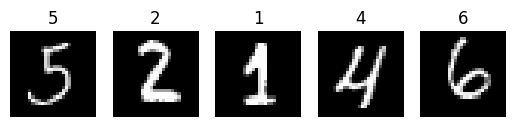

In [6]:
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

Bild egenskaper
* 28x28 pixlar
* Gråskala
* Normaliserad (0–1)
* Vit med svart bakgrund

img = img.resize((28,28)).convert("L")
img = np.array(img) / 255.0
img = 1 - img   # ofta behövs invertering

In [7]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print('X_train')
print(X_train.shape)
print(y_train.shape)

print('X_train')
print(X_test.shape)
print(y_test.shape)

print('X_val')
print(X_val.shape)
print(y_val.shape)


print(type(x_train))
print(type(y_train))

X_train
(36000, 28, 28)
(60000,)
X_train
(12000, 28, 28)
(10000,)
X_val
(12000, 28, 28)
(12000,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Mina första tester visar på otillfredsställande resultat. Skapade egna bilder för att komplettera. Kanske inte nödvändigt.
Lokal app. Finns även som streamlit länk.
https://mnist-pics-s8ciztwncgezrbartfdkuu.streamlit.app/
Brist i den just nu. Filerna sparas i unix. Måste kompletteras om man enkelt vill få ner bilderna lokalt.

## Finns det tillräckligt med data? Fördelning på klasser?

Siffra 0: 5923 bilder
Siffra 1: 6742 bilder
Siffra 2: 5958 bilder
Siffra 3: 6131 bilder
Siffra 4: 5842 bilder
Siffra 5: 5421 bilder
Siffra 6: 5918 bilder
Siffra 7: 6265 bilder
Siffra 8: 5851 bilder
Siffra 9: 5949 bilder


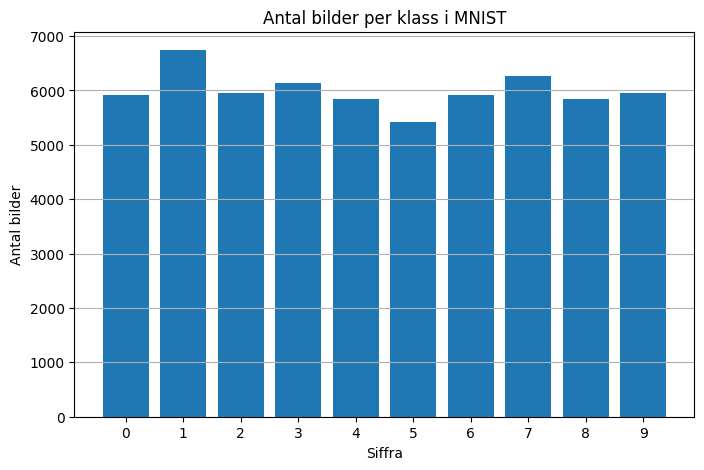

In [8]:
from collections import Counter
import matplotlib.pyplot as plt

# Räkna antal bilder per klass
class_counts = Counter(y_train)

# Visa antal per siffra
for digit in sorted(class_counts.keys()):
    print(f"Siffra {digit}: {class_counts[digit]} bilder")

# Rita stapeldiagram
plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Siffra")
plt.ylabel("Antal bilder")
plt.title("Antal bilder per klass i MNIST")

plt.xticks(range(10))
plt.grid(axis='y')

plt.show()

### Förklaring av egna bilder
Här används egna skapade bilder för att komplettera MNIST-datasetet. Detta kan förbättra modellens förmåga att känna igen variationer som inte finns i originaldatan.

Egna bilder kan bidra till:
- bättre generalisering
- robustare modell
- högre träffsäkerhet på verkliga handskrivna siffror

### App för att skapa MNIST anpassade bilder.

In [9]:
import tkinter as tk
from PIL import Image, ImageDraw
import os

# Create dataset folders
for i in range(10):
    os.makedirs(f"data/{i}", exist_ok=True)

class MNISTDrawer:
    def __init__(self, root):
        self.root = root
        self.root.title("MNIST Drawing App")

        self.canvas_size = 280  # large canvas for drawing
        self.image_size = 28    # MNIST size

        self.canvas = tk.Canvas(root, width=self.canvas_size, height=self.canvas_size, bg="black")
        self.canvas.pack()

        self.canvas.bind("<B1-Motion>", self.draw)

        self.button_frame = tk.Frame(root)
        self.button_frame.pack()

        for i in range(10):
            btn = tk.Button(self.button_frame, text=str(i), command=lambda i=i: self.save(i))
            btn.grid(row=0, column=i)

        self.clear_btn = tk.Button(root, text="Clear", command=self.clear)
        self.clear_btn.pack()

        # PIL image for saving
        self.image = Image.new("L", (self.canvas_size, self.canvas_size), 0)
        self.draw_image = ImageDraw.Draw(self.image)

    def draw(self, event):
        x, y = event.x, event.y
        r = 8

        self.canvas.create_oval(x-r, y-r, x+r, y+r, fill="white", outline="white")
        self.draw_image.ellipse([x-r, y-r, x+r, y+r], fill=255)

    def clear(self):
        self.canvas.delete("all")
        self.image = Image.new("L", (self.canvas_size, self.canvas_size), 0)
        self.draw_image = ImageDraw.Draw(self.image)

    def save(self, label):
        # Resize to MNIST size
        img = self.image.resize((self.image_size, self.image_size))

        # Save image
        count = len(os.listdir(f"data/{label}"))
        filename = f"data/{label}/{count}.png"
        img.save(filename)

        print(f"Saved {filename}")
        self.clear()

if __name__ == "__main__":
    root = tk.Tk()
    app = MNISTDrawer(root)
    root.mainloop()

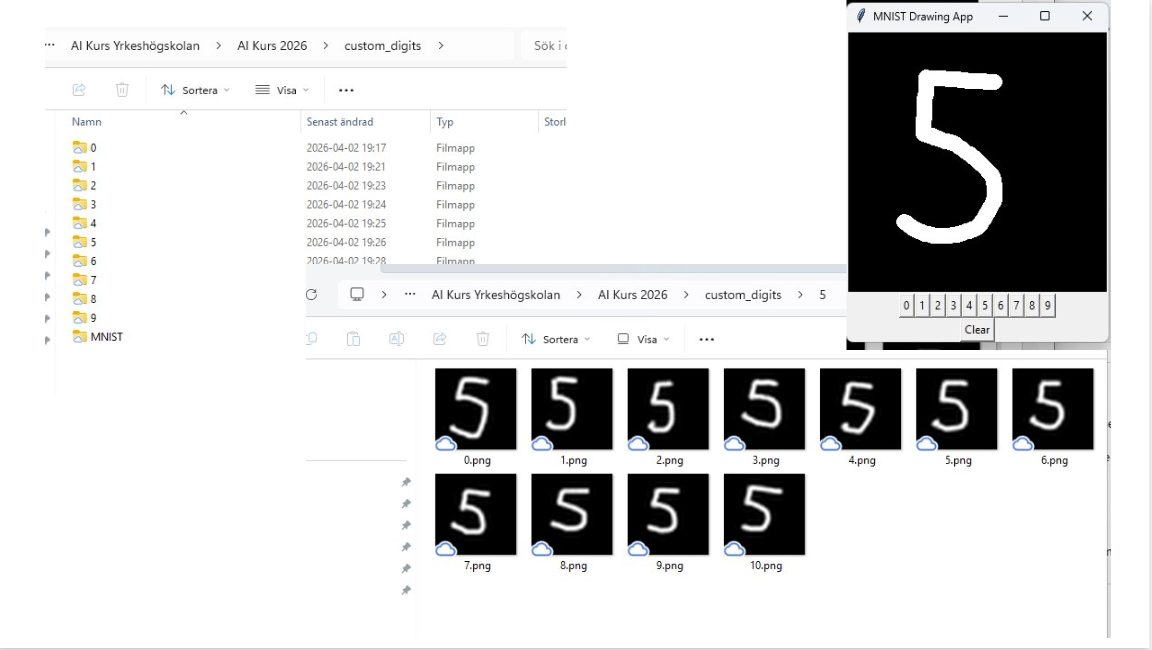

### Kod för import av kundspecifika bilder

### Bildbehandling

### - Läs in bild
### - Ändra storlek till 28×28
### - Invertera färger (vid behov)
### - Konvertera till numpy-array
### - Flatten till 784 features
### - Normalisera pixelvärden
### - Lägg till i dataset

img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (28,28))

img = 255 - img

img = img.reshape(784)

img = img / 255.0

In [10]:
# Pillow bibliotek
from PIL import Image

In [11]:
# CUSTOM PICS

import os

import numpy as np


data = []
labels = []

path = ".\data"

for label in range(10):
    folder = os.path.join(path, str(label))
    
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        
        # Open image
        img = Image.open(img_path).convert('L')  # grayscale
        
        # Resize to 28x28
        #img = img.resize((28, 28))
        
        # Invert colors (IMPORTANT for MNIST!)
        # img = 255 - img
               
        data.append(img)
        labels.append(label)

# Convert to numpy
X_custom = np.array(data)
y_custom = np.array(labels)

print(X_custom.shape)

X_custom = X_custom.reshape(-1, 784)

# Normalize
X_custom = X_custom / 255.0

print(X_custom.shape)  # (num_images, 28, 28 -> 1D-array 784 värden)
print(X_custom.min())
print(X_custom.max())

(116, 28, 28)
(116, 784)
0.0
1.0


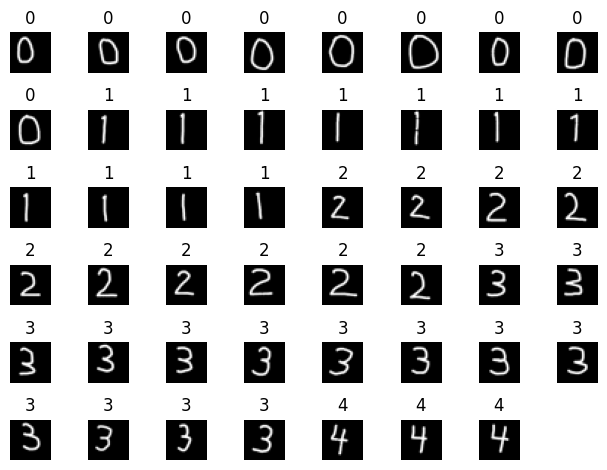

In [12]:
import matplotlib.pyplot as plt

for i in range(1, 48):

    plt.subplot(6, 8, i)

    plt.imshow(X_custom[i].reshape(28,28), cmap='gray')

    plt.title(y_custom[i])

    plt.axis('off')

plt.tight_layout()
plt.show()

### Förklaring av normalisering
Normalisering innebär att pixelvärden skalas om från intervallet 0–255 till 0–1.

Detta görs eftersom:
- modellen tränar stabilare
- gradient descent fungerar bättre
- träningen blir snabbare

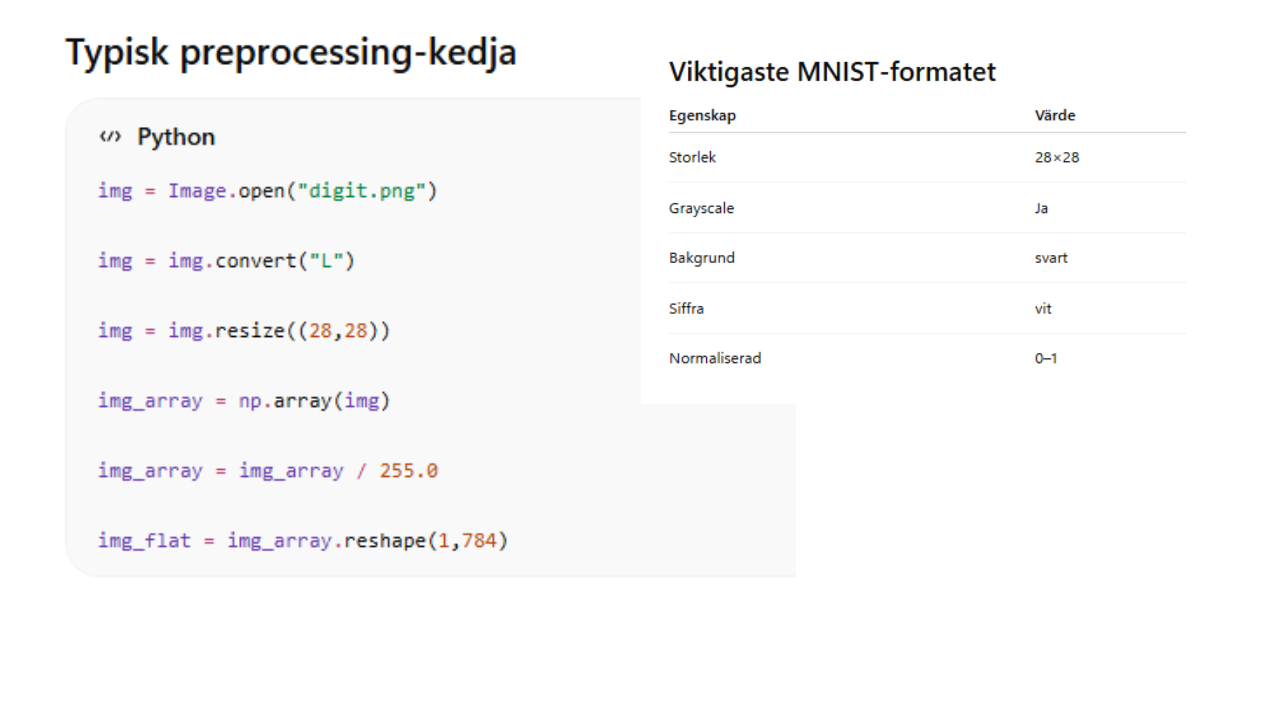

### Skapar X_combine och y_combine med både MNIST och egna bilder.

In [13]:
# import katalog
print(os.getcwd())

G:\Min enhet\AI_prov\mnist-start


## Mina modeller
- ExtraTreesClassifier
- 
- SVC
- RF Random Forest
- MNN
- CNN 

In [71]:
from tensorflow.keras.datasets import mnist
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# -----------------------------------
# Load MNIST
# -----------------------------------

(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

# Flatten
X_train_mnist = X_train_mnist.reshape(-1, 784)
X_test_mnist = X_test_mnist.reshape(-1, 784)

# Normalize ONCE!
X_train_mnist = X_train_mnist / 255.0
X_test_mnist = X_test_mnist / 255.0

X_combine = np.concatenate((X_train_mnist, X_custom), axis=0)
y_combine = np.concatenate((y_train_mnist, y_custom), axis=0)

print(X_combine.shape)
print(y_combine.shape)

# -----------------------------------
# Model
# -----------------------------------

model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_combine, y_combine)

# Predict
y_pred_combine = model.predict(X_test_mnist)


# Accuracy

acc = accuracy_score(y_test, y_pred_combine)

print("Accuracy:", acc)




(60116, 784)
(60116,)
Accuracy: 0.9741


In [72]:
print(X_train_mnist.min(), X_train_mnist.max())
print(X_test_mnist.min(), X_test_mnist.max())
print(X_custom.min(), X_custom.max())

0.0 1.0
0.0 1.0
0.0 1.0


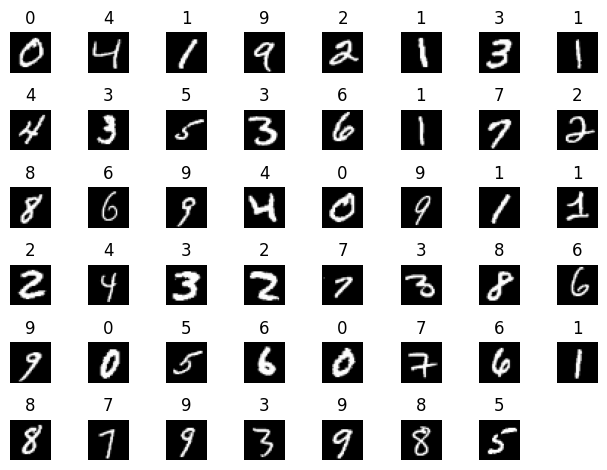

In [73]:
import matplotlib.pyplot as plt

for i in range(1, 48):

    plt.subplot(6, 8, i)

    plt.imshow(X_train_mnist[i].reshape(28,28), cmap='gray')

    plt.title(y_train_mnist[i])

    plt.axis('off')

plt.tight_layout()
plt.show()

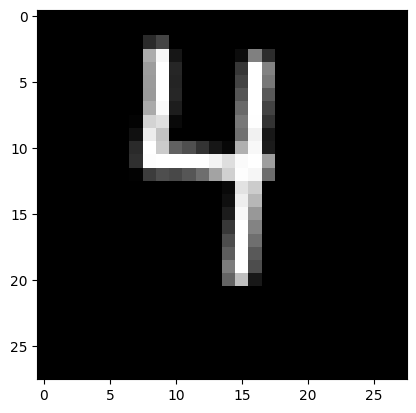

In [97]:
import matplotlib.pyplot as plt

plt.imshow(X_custom[53].reshape(28,28), cmap="gray")
plt.show()

In [77]:
print('X_test')
print(X_test_mnist.shape)  # (num_images, 28, 28)
print(X_test_mnist.min())
print(X_test_mnist.max())
print('X_train')
print(X_train_mnist.shape)  # (num_images, 28, 28)
print(X_train_mnist.min())
print(X_train_mnist.max())
print('X_custom')
print(X_custom.shape)  # (num_images, 28, 28)
print(X_custom.min())
print(X_custom.max())
print()
# y_pred = model.predict(X_test_mnist)

print(y_pred_combine[:20])
print(y_test[:20])




X_test
(10000, 784)
0.0
1.0
X_train
(60000, 784)
0.0
1.0
X_custom
(116, 784)
0.0
1.0

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [78]:
pred_labels = model.predict(X_test_mnist)

wrong = np.where(pred_labels != y_test_mnist)[0]

print("Number of wrong predictions:", len(wrong))

Number of wrong predictions: 259


In [79]:
#pred_labels = np.argmax(pred, axis=1)

errors = np.where(pred_labels != y_test_mnist)[0]

# count errors per digit
counts = {i: 0 for i in range(10)}

for i in errors:
    counts[y_test_mnist[i]] += 1

print("Errors per digit:", counts)

# worst digit
worst_digit = max(counts, key=counts.get)
print("Worst digit:", worst_digit)

Errors per digit: {0: 7, 1: 12, 2: 31, 3: 27, 4: 25, 5: 26, 6: 19, 7: 33, 8: 36, 9: 43}
Worst digit: 9


In [80]:
print('X_train_mnist')
print(X_train_mnist.shape)
print(y_train_mnist.shape)
print('X_test_mnist')
print(X_test_mnist.shape)
print(y_test_mnist.shape)
print('X_custom')
print(X_custom.shape)
print(y_custom.shape)
print('X_combine')
print(X_combine.shape)
print(y_combine.shape)

print()
print(y_combine.dtype)
print(np.unique(y_combine))


X_train_mnist
(60000, 784)
(60000,)
X_test_mnist
(10000, 784)
(10000,)
X_custom
(116, 784)
(116,)
X_combine
(60116, 784)
(60116,)

int64
[0 1 2 3 4 5 6 7 8 9]


# 3. Dela upp data

### Förklaring av train/test-split
Datan delas upp i träningsdata och testdata.

- Träningsdata används för att lära modellen.
- Testdata används för att kontrollera hur bra modellen fungerar på ny data.

Detta är viktigt för att undvika överanpassning (overfitting).

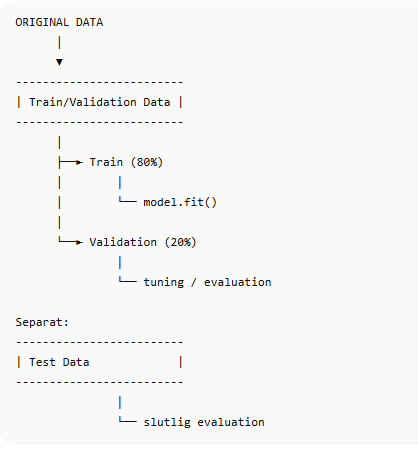

In [95]:
# -----------------------------------
# Första split:
# Train + Validation / Test
# -----------------------------------

from sklearn.model_selection import train_test_split


X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_combine,
    y_combine,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# Storlekar
# -----------------------------------

print("Training:", X_train_final.shape)
print("Validation:", X_val_final.shape)
print("Test:", X_test_mnist.shape)


Training: (48092, 784)
Validation: (12024, 784)
Test: (10000, 784)


In [96]:
print("ExtraTreesClassifier accuracy: ",model.score(X_test_mnist, y_test_mnist))

print("ExtraTreesClassifier accuracy: ",model.score(X_train_final, y_train_final))


ExtraTreesClassifier accuracy:  0.9714
ExtraTreesClassifier accuracy:  1.0


In [83]:
print(X_train_mnist.min(), X_train_mnist.max())
print(X_test_mnist.min(), X_test_mnist.max())
print(X_custom.min(), X_custom.max())

print(X_train_final.min(), X_train_final.max())



0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0


In [ ]:
model.fit(X_train_final, y_train_final)

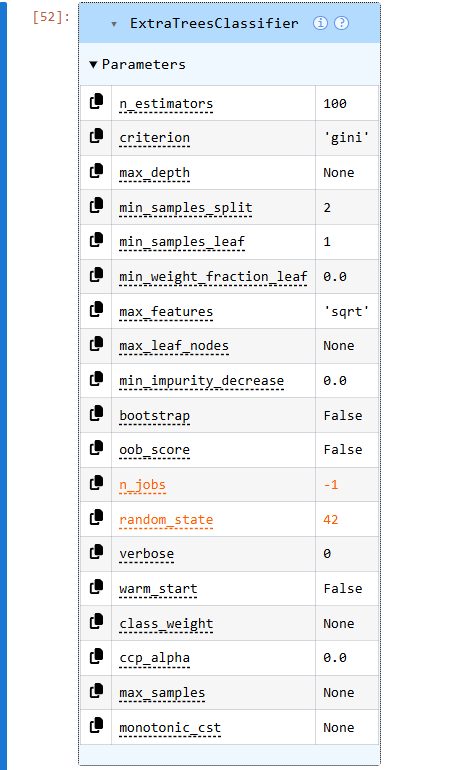

In [87]:
X_val_final_flat = X_val_final.reshape(X_val_final.shape[0], 784)

val_acc = model.score(X_val_final_flat, y_val_final)

print("Validation accuracy:", val_acc)

Validation accuracy: 0.9666500332667998


## Välj modell

## Felaktiga prediktioner

In [99]:
wrong = np.where(y_pred_combine != y_test_mnist)[0]

print("Wrong:", len(wrong))

Wrong: 259


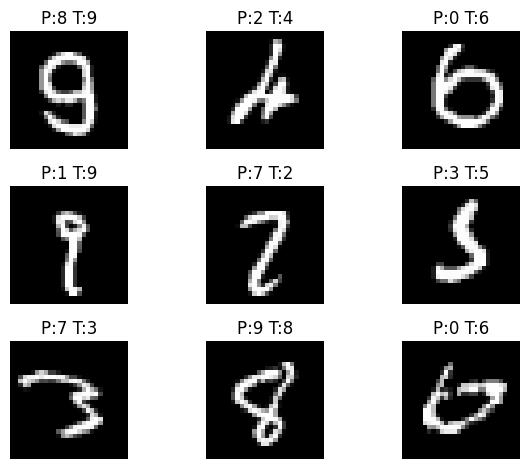

In [100]:
# X.reshape(n_samples, 784)
# img.reshape(28, 28)

idx = wrong[1]

import matplotlib.pyplot as plt

for i in range(9):

    idx = wrong[i]

    img = X_test_mnist[idx].reshape(28, 28)

    plt.subplot(3, 3, i+1)

    plt.imshow(img, cmap="gray")

    plt.title(f"P:{y_pred_combine[idx]} T:{y_test_mnist[idx]}")

    plt.axis("off")

plt.tight_layout()
plt.show()


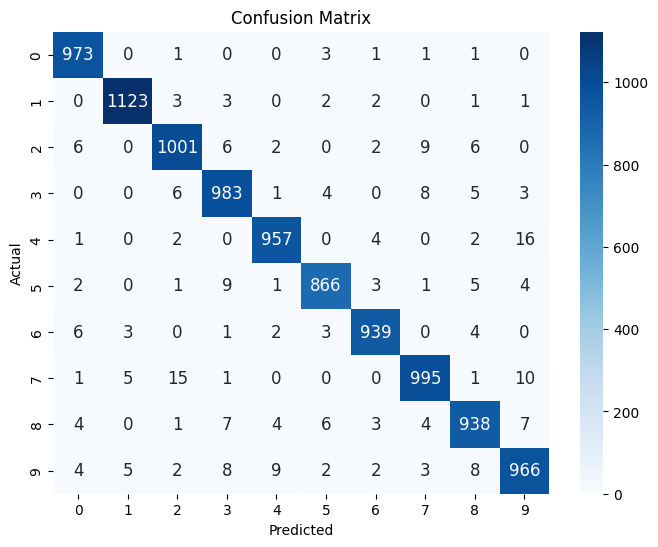

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_mnist, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",  annot_kws={"size": 12})

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Tabellerna

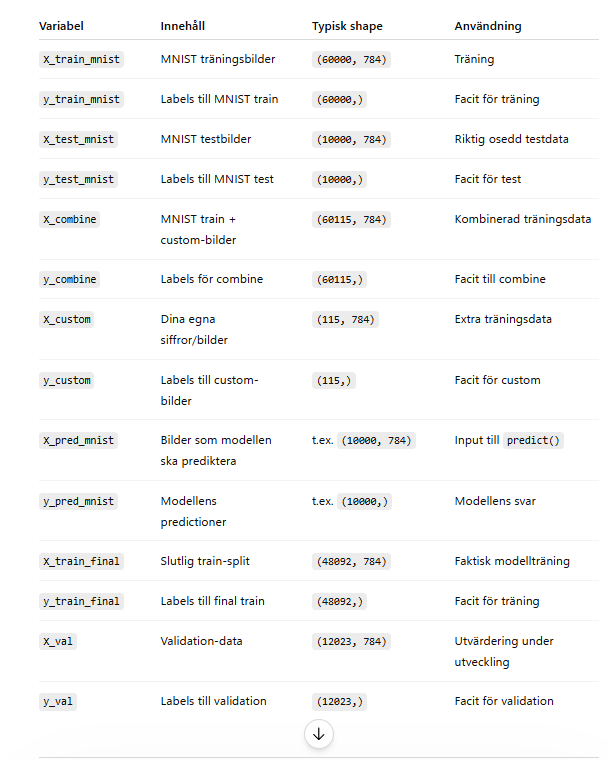

# 4. Feature Engineering

Feature engineering användes för att förbereda bilddatan inför modellträning. 
Bilderna plattades ut från 28×28 pixlar till 784 numeriska features och normaliserades till intervallet 0–1. 
Custom-bilder anpassades dessutom till samma format och pixelrepresentation som MNIST-datasetet.

# 5. Välj modell 
## - LogisticRegression
## - Linjär regression
## - Beslutsträd
## - Random forest
## - MNN
## - CNN
## - Transformers

In [105]:
#Linjär regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=300
)

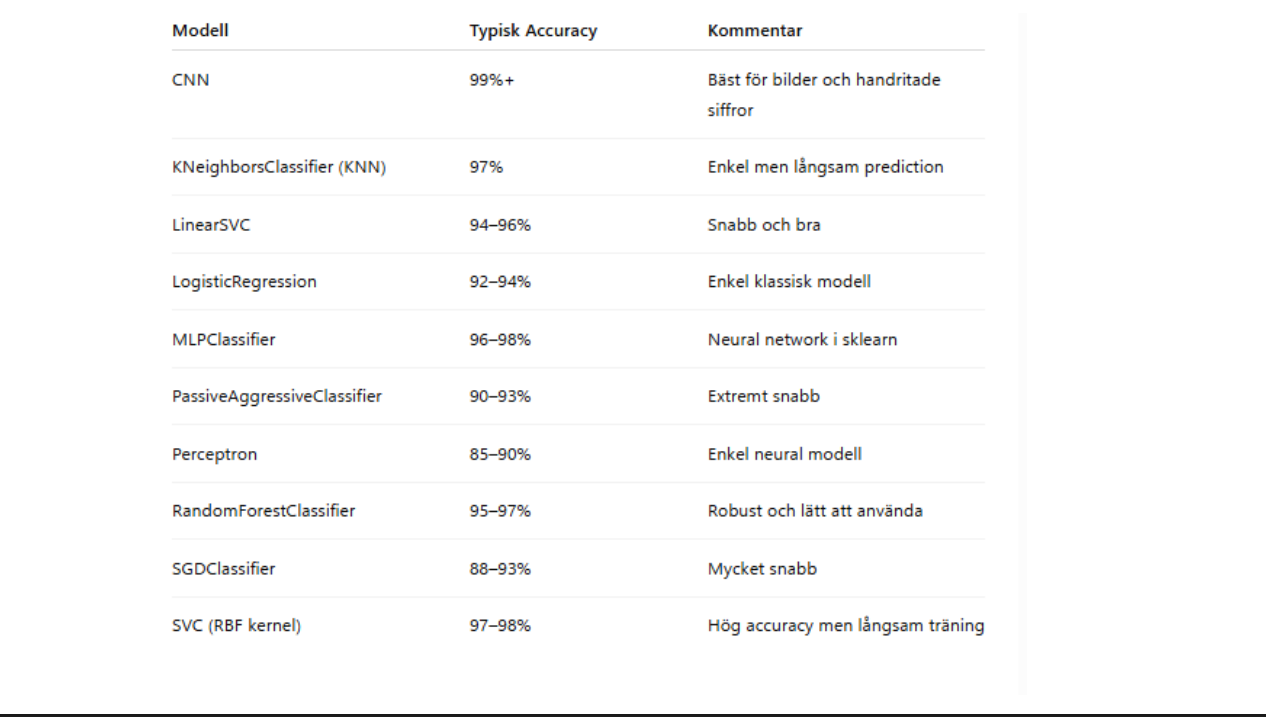

# 6. Träna modellen

In [119]:
# Utvärdering flera modeller
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import *

# Modeller
logreg = LogisticRegression(max_iter=300)

svm = SVC()

rf = RandomForestClassifier()

# Träning
logreg.fit(X_train_mnist, y_train_mnist)
svm.fit(X_train_mnist, y_train_mnist)
rf.fit(X_train_mnist, y_train_mnist)

# Samling
models = {
    "LogReg": logreg,
    "SVM": svm,
    "RF": rf
}



# 7. Utvärdera modellen
## - accuracy
## - precision
## - recall
## - F1-score
## - loss

# Utvärdering


LogReg
Accuracy: 0.9259


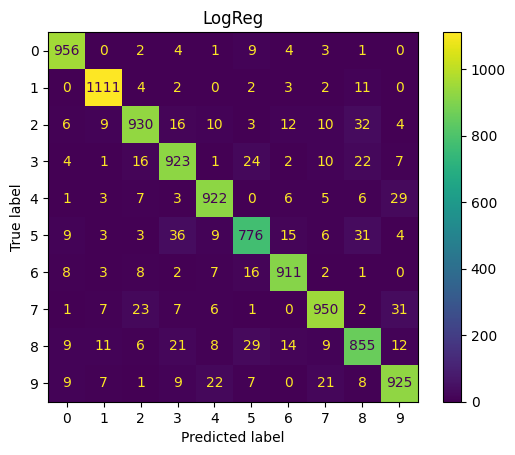

SVM
Accuracy: 0.9792


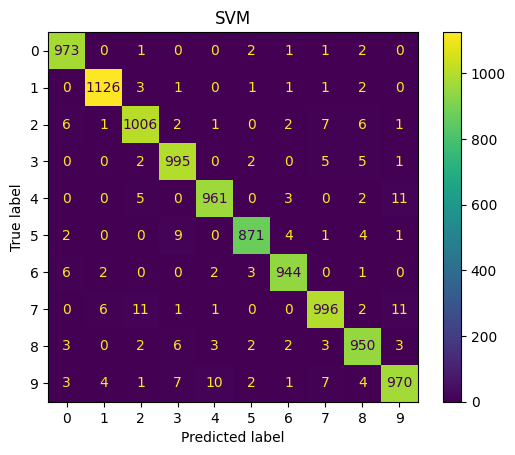

RF
Accuracy: 0.97


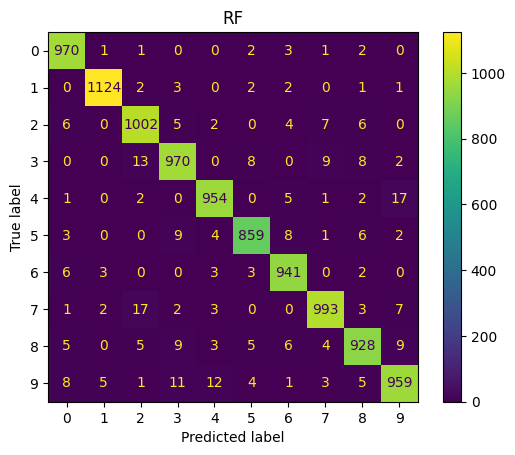

In [120]:
for name, model in models.items():

    y_pred = model.predict(X_test_mnist)

    print(name)
    print("Accuracy:", accuracy_score(y_test_mnist, y_pred))

    ConfusionMatrixDisplay(
        confusion_matrix(y_test_mnist, y_pred)
    ).plot()

    plt.title(name)

    plt.show()

### Förbättra resultatet?

Vad kan man göra för att förbättra prestationsförmågan?
- Ompröva modellval
- Mer data. 
- Bättre kvalitet.
- Bättre Modell 
- Optimering av modellen.

In [121]:
from sklearn.metrics import classification_report

models = {
    "LogReg": logreg,
    "SVM": svm,
    "RF": rf
}

for name, model in models.items():

    y_pred = model.predict(X_test_mnist)

    print("\n", name)

    print(classification_report(y_test_mnist, y_pred))


 LogReg
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.92      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000


 SVM
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
         

In [125]:
print("Training:", X_train_mnist.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_mnist.shape)

Training: (60000, 784)
Validation: (12024, 784)
Test: (10000, 784)


In [126]:

pred_labels = model.predict(X_test_mnist)

wrong = np.where(pred_labels != y_test_mnist)[0]

print("Number of wrong predictions:", len(wrong))

Number of wrong predictions: 300


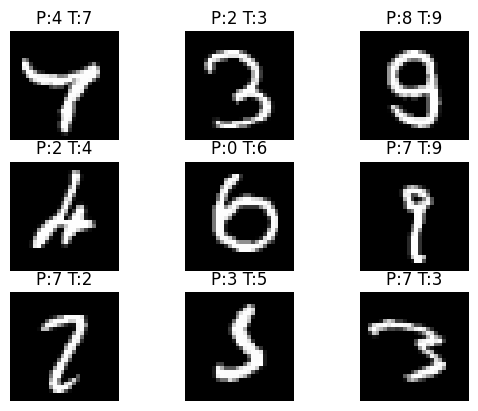

In [127]:
import matplotlib.pyplot as plt

for i in range(9):
    idx = wrong[i]
    
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test_mnist[idx].reshape(28,28), cmap='gray')
    plt.title(f"P:{pred_labels[idx]} T:{y_test_mnist[idx]}")
    plt.axis('off')

plt.show()

In [128]:
#pred_labels = np.argmax(pred, axis=1)

errors = np.where(pred_labels != y_test_mnist)[0]

# count errors per digit
counts = {i: 0 for i in range(10)}

for i in errors:
    counts[y_test_mnist[i]] += 1

print("Errors per digit:", counts)

# worst digit
worst_digit = max(counts, key=counts.get)
print("Worst digit:", worst_digit)

Errors per digit: {0: 10, 1: 11, 2: 30, 3: 40, 4: 28, 5: 33, 6: 17, 7: 35, 8: 46, 9: 50}
Worst digit: 9


# 8. Tuning / Förbättring
- hyperparametrar
- antal lager
- learning rate
- batch size
- optimizer

Gridsearch hittar bästa hyperparametrar för modellen.

### Logistic Regression - förbättringsmöjligheter
### SVM Support Vector Machine. ( MYCKET TIDSKRÄVANDE för MNIST! )
### Random Forest


In [129]:
#Logistic Regression - förbättringsmöjligheter

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    "C": [0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    params,
    cv=3
)

grid.fit(X_train_mnist, y_train_mnist)

print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1}
0.9194


In [81]:
# SVM Support Vector MAchine. MYCKET TIDSKRÄVANDE!

from sklearn.svm import SVC

params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid = GridSearchCV(
    SVC(),
    params,
    cv=3
)

grid.fit(X_train_mnist, y_train_mnist)

print(grid.best_params_)
print(grid.best_score_)

{'C': 10, 'kernel': 'rbf'}
0.9802


In [82]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=3
)

grid.fit(X_train_mnist, y_train_mnist)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 20, 'n_estimators': 100}
0.9640833333333333


# MLP och CNN För bilddata

## MLP Dense Neural Network tabelldata, kunddata

## CNN (Convolutional Neural Network) - Bilder och former

### CNN exempel

In [130]:
#pip install streamlit streamlit-drawable-canvas tensorflow pillow numpy matplotlib

#train_cnn.py
#python Göran_ML_CNN_model.py

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Data augmentation
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------
# Ladda MNIST
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# -----------------------------
# Normalisera
# -----------------------------
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# -----------------------------
# CNN behöver kanal-dimension
# (28,28) -> (28,28,1)
# -----------------------------
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# -----------------------------
# Bygg CNN
# -----------------------------
model = models.Sequential([

#    layers.Conv2D(
#        32,
#        (3, 3),
#        activation="relu",
#        input_shape=(28, 28, 1)
#    ),
   
    layers.Input(shape=(28, 28, 1)),
    
    layers.Conv2D(32, (3,3), activation="relu"),

    layers.MaxPooling2D((2, 2)),

#    layers.Conv2D(
#        64,
#        (3, 3),
#        activation="relu"

    layers.Conv2D(64, (3,3), activation="relu"),              

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        10,
        activation="softmax"
    )
])

# -----------------------------
# Kompilera
# -----------------------------
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# Träna
# -----------------------------
model.fit(
    X_train,
    y_train,
    epochs=10,
    #epochs=10,
    batch_size=64,
    validation_split=0.1
)

# -----------------------------
# Utvärdera
# -----------------------------
loss, acc = model.evaluate(X_test, y_test)

print(f"Accuracy: {acc:.4f}")


# -----------------------------
# Spara accuracy till fil
# -----------------------------
with open("accuracy.txt", "w") as f:
    f.write(f"{acc:.4f}")

print("Modell och accuracy sparad.")

# -----------------------------
# Spara modellen
# -----------------------------
model.save("mnist_cnn.keras")

print("CNN-modell sparad.")



Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9376 - loss: 0.2046 - val_accuracy: 0.9855 - val_loss: 0.0508
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9780 - loss: 0.0695 - val_accuracy: 0.9880 - val_loss: 0.0426
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9848 - loss: 0.0491 - val_accuracy: 0.9875 - val_loss: 0.0469
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9880 - loss: 0.0388 - val_accuracy: 0.9912 - val_loss: 0.0342
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9897 - loss: 0.0331 - val_accuracy: 0.9913 - val_loss: 0.0308
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9910 - loss: 0.0282 - val_accuracy: 0.9910 - val_loss: 0.0351
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9927 - loss: 0.0233 - val_accuracy: 0.9902 - val_loss: 0.0361
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9938 - loss: 0.0205 - val_accuracy: 0.

In [131]:
#Evaluate accuracy
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print("Train accuracy:", train_acc)
print("Train loss:", train_loss)
print()
# Test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)


Train accuracy: 0.9968833327293396
Train loss: 0.01025038305670023

Test accuracy: 0.9908999800682068
Test loss: 0.03258940950036049


### APP för prediktering av ritade bilder.

https://mnist-cnn-app-bappbydwvbjjfcrt63rted4.streamlit.app/

######################################################################

Test med olika optimerare.

######################################################################

In [132]:
import sys
print(sys.version)

3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]


In [133]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


Training with sgd
sgd - Epoch 1: 86.32%
sgd - Epoch 2: 89.30%
sgd - Epoch 3: 90.49%
sgd - Epoch 4: 90.85%
sgd - Epoch 5: 91.48%

Training with momentum
momentum - Epoch 1: 92.63%
momentum - Epoch 2: 94.52%
momentum - Epoch 3: 95.68%
momentum - Epoch 4: 96.31%
momentum - Epoch 5: 96.73%

Training with adam
adam - Epoch 1: 94.82%
adam - Epoch 2: 96.50%
adam - Epoch 3: 97.07%
adam - Epoch 4: 97.51%
adam - Epoch 5: 97.69%

Training with adamw
adamw - Epoch 1: 94.62%
adamw - Epoch 2: 96.22%
adamw - Epoch 3: 96.53%
adamw - Epoch 4: 97.20%
adamw - Epoch 5: 97.32%


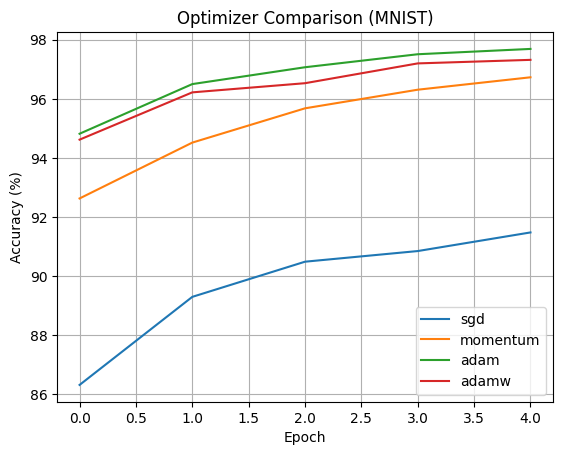

In [134]:
# ===== Data =====
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset  = torchvision.datasets.MNIST(root="./data", train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

# ===== Modell (MLP) =====
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

# ===== Träning =====
def train_model(optimizer_name, epochs=5):
    model = MLP()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_name == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    elif optimizer_name == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=0.001)

    acc_list = []

    for epoch in range(epochs):
        model.train()

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # ===== Test accuracy =====
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        acc_list.append(accuracy)

        print(f"{optimizer_name} - Epoch {epoch+1}: {accuracy:.2f}%")

    return acc_list

# ===== Kör alla optimerare =====
optimizers = ["sgd", "momentum", "adam", "adamw"]
results = {}

for opt in optimizers:
    print(f"\nTraining with {opt}")
    results[opt] = train_model(opt, epochs=5)

# ===== Plot =====
plt.figure()

for opt in optimizers:
    plt.plot(results[opt], label=opt)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Optimizer Comparison (MNIST)")
plt.legend()
plt.grid()

plt.show()

# 9. Deployment
- webbtjänst
- mobilapp
- självkörande bil
- chatbot

CNN o MLP jämförelse
https://mnist-mlp-cnn-pwlmsb88agkgo6yxc2lugj.streamlit.app/

CNN rita siffra och prediktera
https://mnist-cnn-app-bappbydwvbjjfcrt63rted4.streamlit.app/

# 10. Övervakning
fungerar den fortfarande bra?
har datan förändrats?
behövs omträning?

APPARNA är statiska eftersom modellerna är tränade i förväg och nedsparad på hemmakatalogen.
Avvägning mellan aktuellt innehåll och mycket långsam laddning eller snabb start med sparad modell.

######################################################################